In [1]:

import os
import re
import pandas as pd
import numpy as np

D:\python\notebooks


In [2]:
def get_extra_data (row):
    cabin_to_number={
        "A":0,
        "B":1,
        "C":2,
        "D":3,
        "E":4,
        "F":5,
        "G":6,
        "T":7
    }
    is_female=0
    is_Southampton=0
    is_Queenstown=0
    is_Cherbourg=0
    ########NAME
  
        
   
    if "female" in row["Sex"]:
        is_female=1
       
   
    ###Embarked
    if row["Embarked"] == "Q":
        is_Queenstown =1
    elif row["Embarked"] == "C":
        is_Cherbourg =1
    elif row["Embarked"] == "S":
        is_Southampton = 1
    #Cabin
    if not pd.isna(row["Cabin"]):
        level=cabin_to_number[row["Cabin"][0]]
    else:
        level=3
    return pd.Series([is_female,is_Queenstown,is_Cherbourg,is_Southampton,level])

In [3]:

df = pd.read_csv("./DATASETS/titanic/train.csv",sep=",")
df=df.drop(columns=['PassengerId'])
df[['is_female',"is_Queenstown","is_Cherbourg","is_Southampton","level"]] = df.apply(get_extra_data, axis=1,result_type="expand")





df.tail()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,is_female,is_Queenstown,is_Cherbourg,is_Southampton,level
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S,0,0,0,1,3
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S,1,0,0,1,1
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S,1,0,0,1,3
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C,0,0,1,0,2
890,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q,0,1,0,0,3


In [4]:
df=df.drop(columns=['Name',"Sex","Ticket","Cabin","Embarked"])
print(df.columns)

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'is_female',
       'is_Queenstown', 'is_Cherbourg', 'is_Southampton', 'level'],
      dtype='str')


In [5]:
####Drop carcteristics n-1
df=df.drop(columns=["is_Southampton"])

In [6]:
#conteo = (df['is_special'] ==1  ).sum()
#filtered_df = df[df['is_other'] == 1]
#print(conteo)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Survived       891 non-null    int64  
 1   Pclass         891 non-null    int64  
 2   Age            714 non-null    float64
 3   SibSp          891 non-null    int64  
 4   Parch          891 non-null    int64  
 5   Fare           891 non-null    float64
 6   is_female      891 non-null    int64  
 7   is_Queenstown  891 non-null    int64  
 8   is_Cherbourg   891 non-null    int64  
 9   level          891 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 69.7 KB


In [8]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare,is_female,is_Queenstown,is_Cherbourg,level
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,0.352413,0.086420,0.188552,2.860831
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,0.477990,0.281141,0.391372,0.750088
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,0.000000,0.000000,0.000000,3.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000,0.000000,0.000000,3.000000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,1.000000,0.000000,0.000000,3.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000,1.000000,1.000000,7.000000


In [9]:
df.fillna(df.mean(numeric_only=True), inplace=True)

,Survived,Pclass,Age,SibSp,Parch,Fare,is_female,is_Queenstown,is_Cherbourg,level
0,0,3,22.000000,1,0,7.2500,0,0,0,3
1,1,1,38.000000,1,0,71.2833,1,0,1,2
2,1,3,26.000000,0,0,7.9250,1,0,0,3
3,1,1,35.000000,1,0,53.1000,1,0,0,2
4,0,3,35.000000,0,0,8.0500,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,0,0,0,3
887,1,1,19.000000,0,0,30.0000,1,0,0,1
888,0,3,29.699118,1,2,23.4500,1,0,0,3
889,1,1,26.000000,0,0,30.0000,0,0,1,2


In [10]:
cantidad_nan = df.isna().sum()
print(cantidad_nan)

Survived         0
Pclass           0
Age              0
SibSp            0
Parch            0
Fare             0
is_female        0
is_Queenstown    0
is_Cherbourg     0
level            0
dtype: int64


In [11]:
cantidad_nan = df.isna().sum()
print(cantidad_nan)

Survived         0
Pclass           0
Age              0
SibSp            0
Parch            0
Fare             0
is_female        0
is_Queenstown    0
is_Cherbourg     0
level            0
dtype: int64


In [12]:
import matplotlib.pyplot as plt

In [13]:
key = "Age"
Q1 = df[key].quantile(0.25)
Q3 = df[key].quantile(0.75)

IQR = Q3 - Q1

inferior = Q1 - 1.5 * IQR
superior = Q3 + 1.5 * IQR

outliers = df[(df[key] < inferior) | (df[key] > superior)]

print(len(outliers))

66


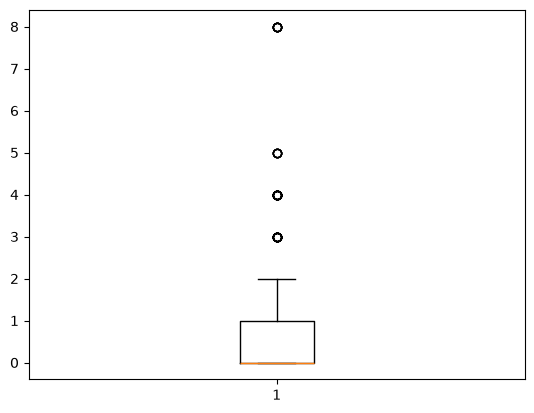

In [14]:
plt.boxplot(df["SibSp"])
plt.show()

In [15]:
###DATA a predecir
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [16]:
from sklearn.model_selection import train_test_split

In [17]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=67
)



In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
#X_train = scaler.fit_transform(X)
#y_train=y

X_test = scaler.transform(X_test)


In [19]:
print(X_train.shape)
print(y_train.shape)

print(np.max(X_train), np.min(X_train))
print(np.max(y_train), np.min(y_train))

print(X_train[:5])
print(y_train[:5])

(712, 9)
(712,)
10.254168965622503 -3.988874355147802
1 0
[[ 0.81628345  1.35401455 -0.48852791 -0.49534593 -0.4706825  -0.72205784
  -0.31156447 -0.47927695  0.17342932]
 [ 0.81628345 -0.51804665 -0.48852791 -0.49534593 -0.50157885  1.38493061
  -0.31156447 -0.47927695  0.17342932]
 [ 0.81628345 -0.05003135 -0.48852791 -0.49534593 -0.46038443 -0.72205784
  -0.31156447 -0.47927695  0.17342932]
 [-0.38951285 -0.51804665 -0.48852791 -0.49534593 -0.34185964 -0.72205784
  -0.31156447  2.08647633  0.17342932]
 [ 0.81628345  0.00450161  0.37672551 -0.49534593 -0.31939693 -0.72205784
  -0.31156447 -0.47927695  0.17342932]]
873    0
649    1
713    0
135    0
639    0
Name: Survived, dtype: int64


In [20]:
for i in range(X_train.shape[1]):
    col_max = np.max(X_train[:, i])
    col_min = np.min(X_train[:, i])
    
    print(i, "min:", col_min, "max:", col_max)

0 min: -1.5953091550379792 max: 0.8162834530024483
1 min: -2.2793442234385664 max: 3.928098697898684
2 min: -0.4885279140549844 max: 6.433499445291263
3 min: -0.49534592637099795 max: 7.400616004438343
4 min: -0.6624529465901146 max: 10.254168965622503
5 min: -0.7220578379655755 max: 1.3849306072454481
6 min: -0.31156447022457073 max: 3.209608590091213
7 min: -0.47927694533343873 max: 2.0864763259252705
8 min: -3.988874355147802 max: 5.7231675530381505


In [27]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


In [21]:
###sklearn linear regression
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=10000)
modelo.fit(X_train,y_train)
y_pred= modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]



In [25]:
###Calculo  log loss
def sigmoide(z):
    return 1 / (1 + np.exp(-z))
epsilon = 1e-15
registros, cualidades = X_train.shape

y_test_pred = sigmoide( np.clip(y_pred, epsilon, 1-epsilon))

loss=L=-np.sum(
    y_test * np.log(y_test_pred) +
    (1 - y_test) * np.log(1 - y_test_pred)
   )/registros
print(loss)

0.15831683963655369


In [28]:
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(f1_score(y_test,y_pred))

[[87 16]
 [20 56]]
0.7988826815642458
0.7777777777777778
0.7368421052631579
0.7567567567567568


In [29]:
print(modelo.coef_)
print(modelo.intercept_)


[[-1.02288255 -0.47459895 -0.35334938 -0.01383249  0.06996058  1.23652798
   0.2158705   0.18773671  0.00460276]]
[-0.72405133]


In [30]:
#para el ejercicio de kaggle utilizare mi modelo...
df_ori = pd.read_csv("./DATASETS/titanic/test.csv",sep=",")
df=df_ori.drop(columns=['PassengerId'])
df[['is_female',"is_Queenstown","is_Cherbourg","is_Southampton","level"]] = df.apply(get_extra_data, axis=1,result_type="expand")


df.tail()


,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,is_female,is_Queenstown,is_Cherbourg,is_Southampton,level
413,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,0,0,0,1,3
414,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,1,0,1,0,2
415,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,0,0,0,1,3
416,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,0,0,0,1,3
417,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C,0,0,1,0,3


In [31]:
df=df.drop(columns=['Name',"Sex","Ticket","Cabin","Embarked"])

print(df.columns)
####Drop carcteristics n-1

df=df.drop(columns=["is_Southampton"])
df.fillna(df.mean(numeric_only=True), inplace=True)
print(X.shape)
print(X_train.shape)
X=df
X = scaler.fit_transform(X)
y_test_pred= sigmoide(modelo.predict(X))

y_test_pred = np.clip(y_test_pred, epsilon, 1-epsilon)
umbral=0.5
y_pred=np.where(y_test_pred > umbral, 1, 0)
print(y_pred)
print(y_pred.shape)

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'is_female', 'is_Queenstown',
       'is_Cherbourg', 'is_Southampton', 'level'],
      dtype='str')
(891, 9)
(712, 9)
[0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 1 1 0 1 1 1 0 1 1
 1 1 0 1 0 1 0 0 0 0 0 0 1 1 1 0 0 0 1 0 1 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0
 1 1 1 1 0 0 1 1 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 1 1 0 1 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1
 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 0 1 1 0 1 0 0 0 0 0 0 0 1 0 1 0 1 0
 1 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 1 1 1 0 1 0 0 0 0 0 1
 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 1 0 0 0 0
 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 0 0 1 1 0 1 0 0 1 1 0
 0 1 0 0 1 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0
 0 1 1 

In [32]:
with open("./respuesta.csv","w") as fo:
    fo.write("PassengerId,Survived\n")
    for index,id_p in enumerate(df_ori['PassengerId']):
        fo.write(f"{id_p},{y_pred[index]}\n")
    